In [ ]:
# KGAT_de14e439df699ce4cce8e3e49751382d

In [ ]:
from google.colab import files
import os
import pandas as pd
import shutil

In [ ]:
# Upload the kaggle.json file you just downloaded
if not os.path.exists("/root/.kaggle/kaggle.json"):
    files.upload()
    !mkdir -p ~/.kaggle
    !cp kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json



# Create a workspace
!mkdir -p skin_cancer_data
%cd skin_cancer_data

# Download HAM10000
!kaggle datasets download -d kmader/skin-cancer-mnist-ham10000
!unzip -q skin-cancer-mnist-ham10000.zip -d ham10000

# Download ISIC 9 Classes
!kaggle datasets download -d nodoubttome/skin-cancer9-classesisic
!unzip -q skin-cancer9-classesisic.zip -d isic9

Saving kaggle (3).json to kaggle (3).json
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
/content/skin_cancer_data
Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
100% 5.20G/5.20G [00:30<00:00, 186MB/s] 

Dataset URL: https://www.kaggle.com/datasets/nodoubttome/skin-cancer9-classesisic
License(s): other
100% 786M/786M [00:05<00:00, 148MB/s]



In [ ]:
# he HAM10000 dataset contains multiple images of the same lesion (lesion_id), if you merge everything into one big master folder (unified_dataset/melanoma) right now and try to split it into Train/Val/Test later, you will accidentally mix images of the same lesion across your training and testing sets.

In [ ]:
import os
import shutil
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit, train_test_split

# 1. Define the Mappings FIRST
ham_mapping = {
    'nv': 'melanocytic_nevi', 'mel': 'melanoma', 'bcc': 'basal_cell_carcinoma',
    'akiec': 'actinic_keratosis', 'bkl': 'benign_keratosis', 'df': 'dermatofibroma',
    'vasc': 'vascular_lesion'
}

isic_mapping = {
    'actinic keratosis': 'actinic_keratosis', 'basal cell carcinoma': 'basal_cell_carcinoma',
    'dermatofibroma': 'dermatofibroma', 'melanoma': 'melanoma', 'nevus': 'melanocytic_nevi',
    'pigmented benign keratosis': 'benign_keratosis', 'seborrheic keratosis': 'benign_keratosis',
    'squamous cell carcinoma': 'squamous_cell_carcinoma', 'vascular lesion': 'vascular_lesion'
}

# 2. NOW Define Master Directories using the mappings
base_dir = 'unified_dataset'
for split in ['train', 'val', 'test']:
    for class_name in set(ham_mapping.values()).union(set(isic_mapping.values())):
        os.makedirs(os.path.join(base_dir, split, class_name), exist_ok=True)

# --- PROCESS HAM10000 (With Lesion ID Protection) ---
print("Processing HAM10000 safely...")
metadata = pd.read_csv('ham10000/HAM10000_metadata.csv')
ham_folders = ['ham10000/ham10000_images_part_1', 'ham10000/ham10000_images_part_2']

# Split safely using lesion_id
gss_test = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_val_idx, test_idx = next(gss_test.split(metadata, groups=metadata['lesion_id']))
df_train_val = metadata.iloc[train_val_idx]
df_test = metadata.iloc[test_idx]

gss_val = GroupShuffleSplit(n_splits=1, test_size=0.10, random_state=42)
train_idx, val_idx = next(gss_val.split(df_train_val, groups=df_train_val['lesion_id']))
df_train = df_train_val.iloc[train_idx]
df_val = df_train_val.iloc[val_idx]

# Helper function to move files based on their assigned split
def move_ham_files(df, split_name):
    for _, row in df.iterrows():
        label = ham_mapping[row['dx']]
        img_name = row['image_id'] + '.jpg'
        dest = os.path.join(base_dir, split_name, label, img_name)

        for folder in ham_folders:
            src = os.path.join(folder, img_name)
            if os.path.exists(src):
                shutil.copy(src, dest)
                break

move_ham_files(df_train, 'train')
move_ham_files(df_val, 'val')
move_ham_files(df_test, 'test')

# --- PROCESS ISIC 9 CLASSES ---
# Assuming ISIC9 doesn't have lesion_ids, we can do standard random splits
print("Processing ISIC 9 Classes...")
isic_root = 'isic9/Skin cancer ISIC The International Skin Imaging Collaboration'

for split_folder in ['Train', 'Test']: # From raw ISIC9
    split_path = os.path.join(isic_root, split_folder)
    if not os.path.exists(split_path): continue

    for folder_name in os.listdir(split_path):
        if folder_name in isic_mapping:
            target_label = isic_mapping[folder_name]
            src_folder = os.path.join(split_path, folder_name)
            images = os.listdir(src_folder)

            # If it's from the original 'Train' folder, we split it into our Train/Val
            if split_folder == 'Train':
                train_imgs, val_imgs = train_test_split(images, test_size=0.10, random_state=42)
                for img in train_imgs:
                    shutil.copy(os.path.join(src_folder, img), os.path.join(base_dir, 'train', target_label, img))
                for img in val_imgs:
                    shutil.copy(os.path.join(src_folder, img), os.path.join(base_dir, 'val', target_label, img))

            # If it's from the original 'Test' folder, it goes to our Master Test
            elif split_folder == 'Test':
                for img in images:
                    shutil.copy(os.path.join(src_folder, img), os.path.join(base_dir, 'test', target_label, img))

print("Merging Complete! Your data is safely split in 'unified_dataset/train', 'val', and 'test'.")

Processing HAM10000 safely...
Processing ISIC 9 Classes...
Merging Complete! Your data is safely split in 'unified_dataset/train', 'val', and 'test'.


/tmp/ipykernel_13834/4119692893.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(class_counts.values()), y=list(class_counts.keys()), palette="viridis")


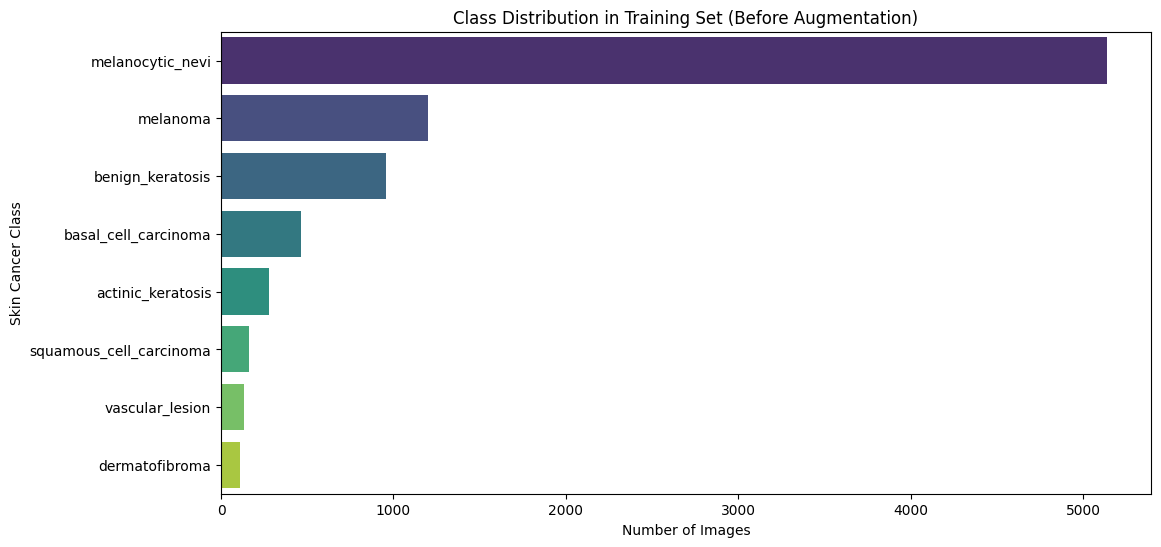

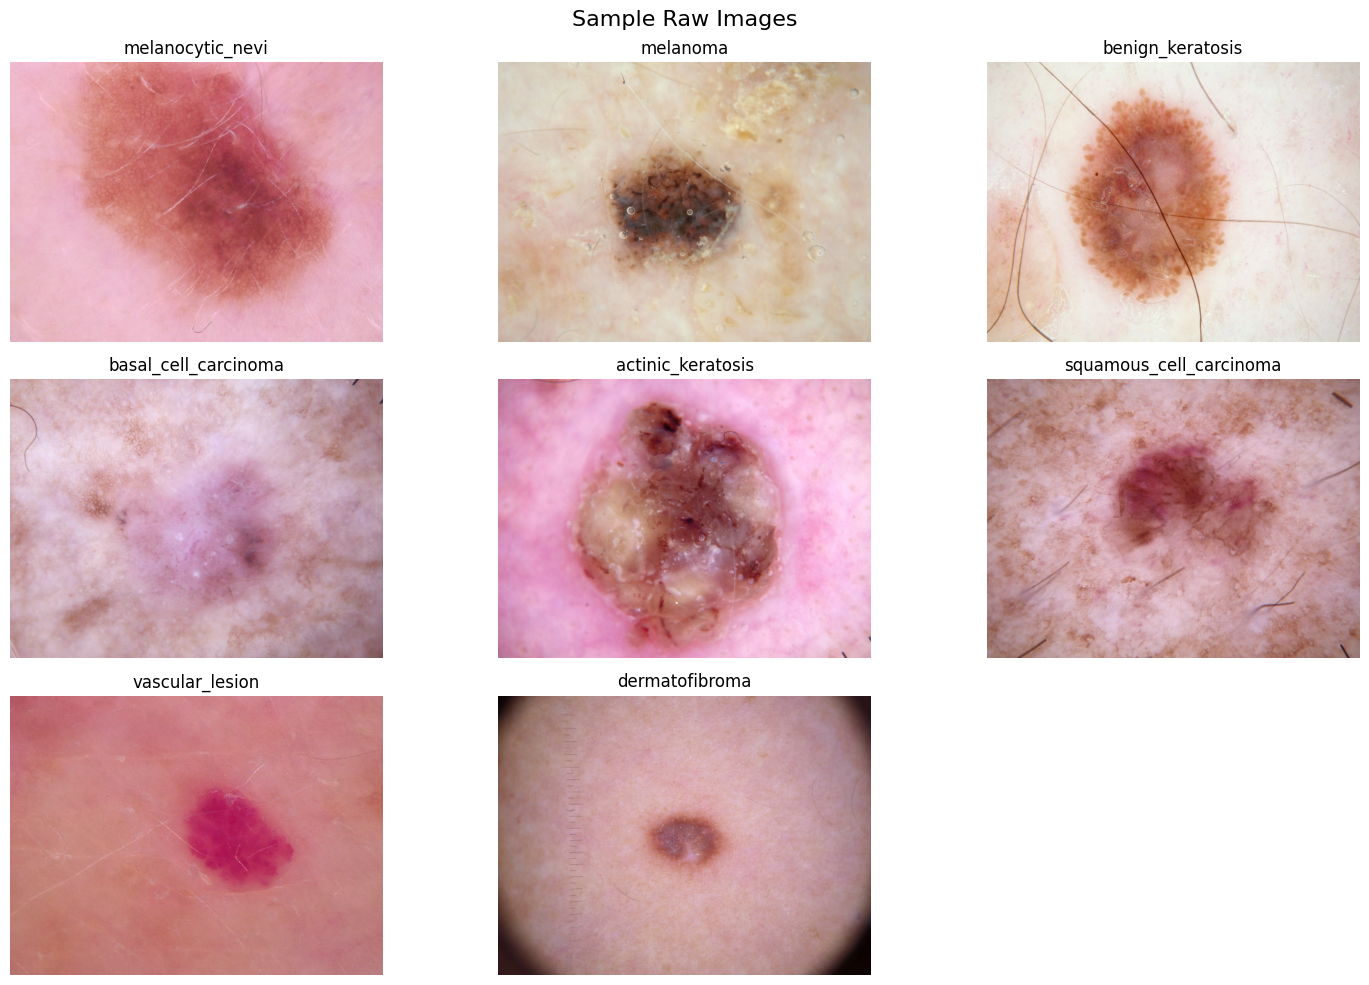

In [ ]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import cv2
import random

train_dir = 'unified_dataset/train'

# 1. Test the Class Imbalance
class_counts = {}
for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        class_counts[class_name] = len(os.listdir(class_path))

class_counts = dict(sorted(class_counts.items(), key=lambda item: item[1], reverse=True))

plt.figure(figsize=(12, 6))
sns.barplot(x=list(class_counts.values()), y=list(class_counts.keys()), palette="viridis")
plt.title('Class Distribution in Training Set (Before Augmentation)')
plt.xlabel('Number of Images')
plt.ylabel('Skin Cancer Class')
plt.show()

# 2. Show a Grid of Raw Data
plt.figure(figsize=(15, 10))
plt.suptitle("Sample Raw Images", fontsize=16)

for i, class_name in enumerate(class_counts.keys()):
    class_path = os.path.join(train_dir, class_name)
    images = os.listdir(class_path)
    random_image_name = random.choice(images)
    img_path = os.path.join(class_path, random_image_name)

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm # Gives you a progress bar

input_base_dir = 'unified_dataset'
output_base_dir = 'preprocessed_dataset'

# 1. Replicate the folder structure for the preprocessed dataset
for split in ['train', 'val', 'test']:
    classes = [
        'melanocytic_nevi', 'melanoma', 'basal_cell_carcinoma',
        'actinic_keratosis', 'benign_keratosis', 'dermatofibroma',
        'vascular_lesion', 'squamous_cell_carcinoma'
    ]
    for class_name in classes:
        os.makedirs(os.path.join(output_base_dir, split, class_name), exist_ok=True)

# 2. Define the Hair Removal Function
def apply_hair_removal(img):
    grayScale = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (17, 17))
    blackhat = cv2.morphologyEx(grayScale, cv2.MORPH_BLACKHAT, kernel)
    _, threshold_mask = cv2.threshold(blackhat, 10, 255, cv2.THRESH_BINARY)
    inpainted_image = cv2.inpaint(img, threshold_mask, 1, cv2.INPAINT_TELEA)
    return inpainted_image

# 3. Process All Images
print("Starting Hair Removal Pipeline. This will take a while...")

for split in ['train', 'val', 'test']:
    split_dir = os.path.join(input_base_dir, split)
    if not os.path.exists(split_dir): continue

    print(f"\nProcessing {split.upper()} set...")
    for class_name in os.listdir(split_dir):
        class_dir = os.path.join(split_dir, class_name)
        if not os.path.isdir(class_dir): continue

        images = os.listdir(class_dir)

        for img_name in tqdm(images, desc=f"Cleaning {class_name}"):
            src_path = os.path.join(class_dir, img_name)
            dest_path = os.path.join(output_base_dir, split, class_name, img_name)

            img = cv2.imread(src_path)
            if img is not None:
                # Apply the paper's preprocessing step
                clean_img = apply_hair_removal(img)
                cv2.imwrite(dest_path, clean_img)

print("\nPreprocessing Complete! Your clean data is now in 'preprocessed_dataset/'.")

Starting Hair Removal Pipeline. This will take a while...

Processing TRAIN set...


Cleaning melanoma: 100%|██████████| 1200/1200 [01:59<00:00, 10.06it/s]



Processing VAL set...


Cleaning melanoma: 100%|██████████| 115/115 [00:15<00:00,  7.42it/s]



Processing TEST set...


Cleaning melanoma: 100%|██████████| 252/252 [00:15<00:00, 16.46it/s]


Preprocessing Complete! Your clean data is now in 'preprocessed_dataset/'.


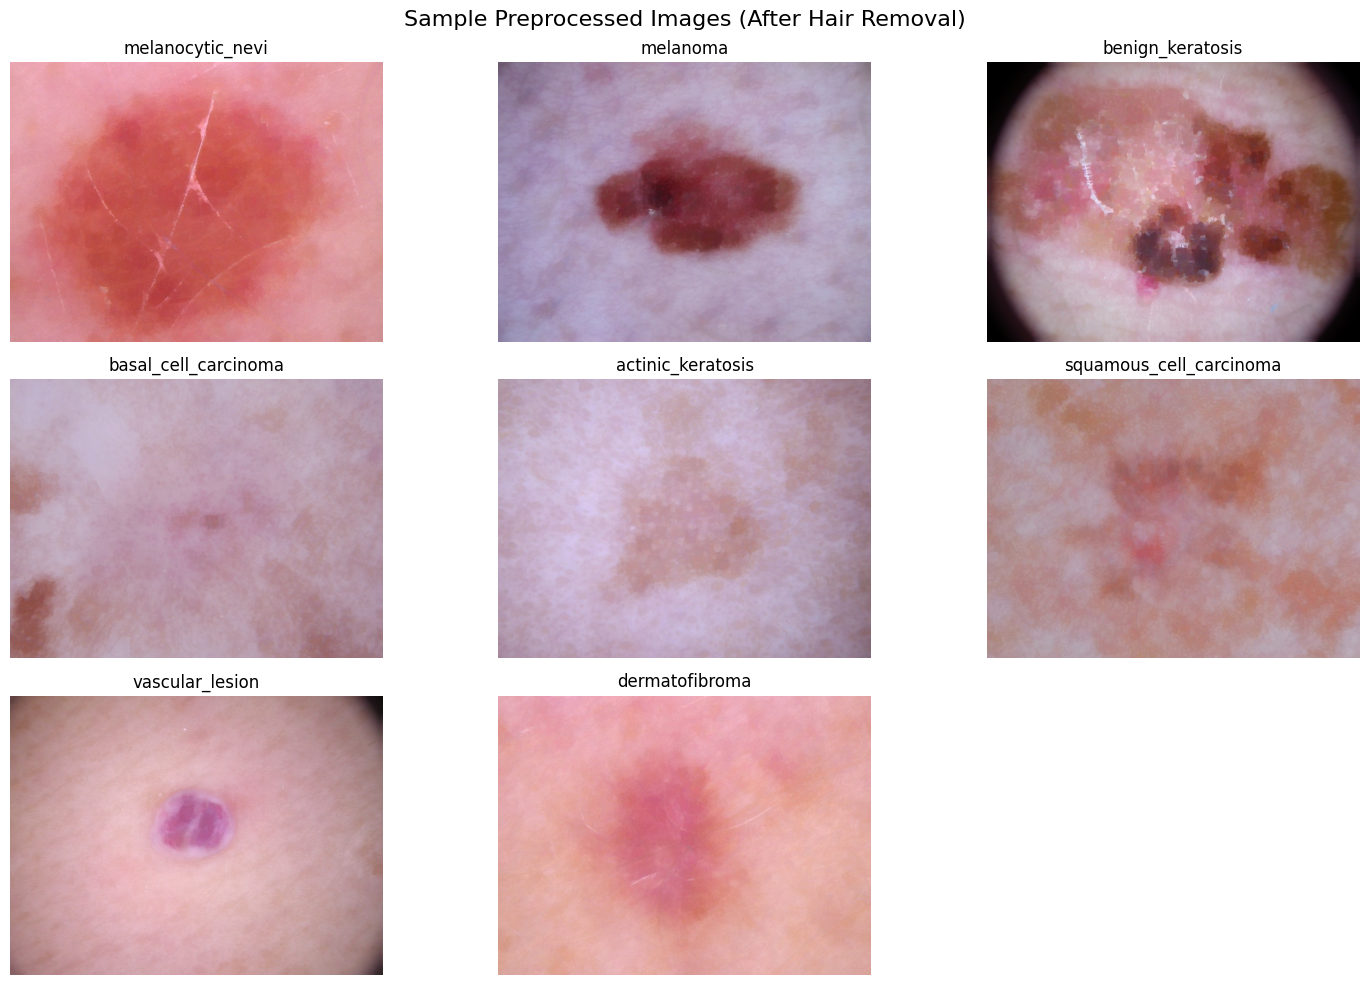

In [ ]:
import os
import matplotlib.pyplot as plt
import cv2
import random

preprocessed_train_dir = 'preprocessed_dataset/train'

# Get class counts for the preprocessed dataset
preprocessed_class_counts = {}
for class_name in os.listdir(preprocessed_train_dir):
    class_path = os.path.join(preprocessed_train_dir, class_name)
    if os.path.isdir(class_path):
        preprocessed_class_counts[class_name] = len(os.listdir(class_path))

preprocessed_class_counts = dict(sorted(preprocessed_class_counts.items(), key=lambda item: item[1], reverse=True))

# Display a grid of sample preprocessed images
plt.figure(figsize=(15, 10))
plt.suptitle("Sample Preprocessed Images (After Hair Removal)", fontsize=16)

for i, class_name in enumerate(preprocessed_class_counts.keys()):
    class_path = os.path.join(preprocessed_train_dir, class_name)
    images = os.listdir(class_path)
    if not images: # Skip if no images in class
        continue
    random_image_name = random.choice(images)
    img_path = os.path.join(class_path, random_image_name)

    img = cv2.imread(img_path)
    if img is None: # Skip if image couldn't be loaded
        print(f"Warning: Could not load image {img_path}")
        continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(3, 3, i + 1) # Adjust subplot grid if there are more/fewer classes
    plt.imshow(img)
    plt.title(class_name)
    plt.axis('off')

plt.tight_layout()
plt.show()

# Data Augmentation

In [ ]:
!git clone https://github.com/fabioperez/skin-data-augmentation.git

Cloning into 'skin-data-augmentation'...
remote: Enumerating objects: 53, done.
remote: Total 53 (delta 0), reused 0 (delta 0), pack-reused 53 (from 1)
Receiving objects: 100% (53/53), 3.71 MiB | 8.45 MiB/s, done.
Resolving deltas: 100% (12/12), done.


In [ ]:
import os
import random
from PIL import Image
from torchvision import transforms
from tqdm import tqdm

# 2. Define your training directory
train_dir = 'preprocessed_dataset/train'

# 3. Define the Fábio Perez Augmentation Pipeline
# Extracted directly from the methodology in the 2018 MICCAI paper
perez_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    # Affine: Rotates up to 90 degrees, shifts by 10%, and scales in/out
    transforms.RandomAffine(degrees=90, translate=(0.1, 0.1), scale=(0.8, 1.2)),
    # Color Jitter: Simulates different lighting conditions and camera types
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1)
])

# 4. Calculate the Imbalance
class_counts = {c: len(os.listdir(os.path.join(train_dir, c))) for c in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, c))}
max_count = max(class_counts.values())
majority_class = max(class_counts, key=class_counts.get)

print(f"The majority class is '{majority_class}' with {max_count} images.")
print("Starting Offline Data Augmentation. Balancing all classes to match...\n")

# 5. Augment the Minority Classes
for class_name, count in class_counts.items():
    if count == max_count:
        print(f"Skipping {class_name} (Already at max count: {max_count})")
        continue

    print(f"Augmenting {class_name} (Current: {count} -> Target: {max_count})")
    class_path = os.path.join(train_dir, class_name)
    existing_images = os.listdir(class_path)

    images_needed = max_count - count

    # tqdm creates a progress bar for the generation process
    for i in tqdm(range(images_needed)):
        # Pick a random image from the existing ones to alter
        random_img_name = random.choice(existing_images)
        img_path = os.path.join(class_path, random_img_name)

        # Open it using PIL (required for torchvision transforms)
        img = Image.open(img_path)

        # Apply the Perez transformations
        aug_img = perez_transforms(img)

        # Save the new augmented image physically to the hard drive
        new_img_name = f"aug_perez_{i}_{random_img_name}"
        aug_img.save(os.path.join(class_path, new_img_name))

print("\nOffline Augmentation Complete! Your training set is now 100% perfectly balanced.")

The majority class is 'melanocytic_nevi' with 5138 images.
Starting Offline Data Augmentation. Balancing all classes to match...

Augmenting squamous_cell_carcinoma (Current: 162 -> Target: 5138)


100%|██████████| 4976/4976 [02:40<00:00, 31.04it/s]


Augmenting dermatofibroma (Current: 109 -> Target: 5138)


100%|██████████| 5029/5029 [02:36<00:00, 32.18it/s]


Augmenting basal_cell_carcinoma (Current: 465 -> Target: 5138)


...

Augmenting vascular_lesion (Current: 136 -> Target: 5138)


100%|██████████| 5002/5002 [02:34<00:00, 32.41it/s]


Skipping melanocytic_nevi (Already at max count: 5138)
Augmenting melanoma (Current: 1200 -> Target: 5138)


100%|██████████| 3938/3938 [06:09<00:00, 10.66it/s]


Offline Augmentation Complete! Your training set is now 100% perfectly balanced.


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
from torchvision import transforms

# ==========================================
# 1. Hair Removal (Black-Hat + Fast Marching)
# ==========================================
def apply_hair_removal(img_path):
    """
    Reads an image and applies the paper's morphological black-hat
    and Fast Marching Method (Telea) inpainting to remove hair noise.
    """
    # Read the image in BGR format
    img = cv2.imread(img_path)
    if img is None:
        raise ValueError(f"Could not read image at {img_path}")

    # Convert original to RGB for the final output
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Convert to grayscale for morphological operations
    grayScale = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Apply Morphological Black-Hat transform to isolate dark hair strands
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (17, 17))
    blackhat = cv2.morphologyEx(grayScale, cv2.MORPH_BLACKHAT, kernel)

    # Create a mask by thresholding the blackhat image
    _, threshold_mask = cv2.threshold(blackhat, 10, 255, cv2.THRESH_BINARY)

    # Inpaint the image using the Fast Marching Method (cv2.INPAINT_TELEA)
    inpainted_image = cv2.inpaint(img_rgb, threshold_mask, 1, cv2.INPAINT_TELEA)

    return inpainted_image

# ==========================================
# 2 & 3. Scaling and Data Augmentation
# ==========================================
def get_augmentation_pipeline(efficientnet_size):
    """
    Applies the paper's scaling, rotation, zooming, and flipping.
    """
    return transforms.Compose([
        # Convert the numpy array from OpenCV to a PIL Image
        transforms.ToPILImage(),

        # 2. Resolution Scaling (match your EfficientNet variant)
        transforms.Resize((efficientnet_size, efficientnet_size)),

        # 3. Augmentations explicitly mentioned in Section 3.1
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(degrees=45),         # Rotation
        transforms.RandomAffine(degrees=0, scale=(0.8, 1.2)), # Zooming

        # Final conversion to tensor for PyTorch
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

# ==========================================
# Example Execution
# ==========================================
if __name__ == "__main__":
    # Example usage: Change to a valid image path in your dataset
    example_path = '/content/skin_cancer_data/unified_dataset/train/melanoma/ISIC_0000142.jpg'

    try:
        # Step 1: Remove Hair
        clean_img_array = apply_hair_removal(example_path)

        # Step 2: Define pipeline for EfficientNet-B4 (380x380 resolution)
        pipeline = get_augmentation_pipeline(efficientnet_size=380)

        # Step 3: Apply Scaling and Augmentation
        final_tensor = pipeline(clean_img_array)

        print("Pipeline execution successful!")
        print(f"Final Tensor Shape: {final_tensor.shape}") # Expected: [3, 380, 380]

    except Exception as e:
        print(f"Error: {e}")

Pipeline execution successful!
Final Tensor Shape: torch.Size([3, 380, 380])


In [ ]:
import torch
import torch.nn as nn
from torchvision import models

def build_efficientnet_b4_from_diagram(num_classes=8):
    """
    Builds the exact model specified in the supplementary block diagrams.
    """
    # 1. Load Pre-trained EfficientNet-B4
    weights = models.EfficientNet_B4_Weights.IMAGENET1K_V1
    model = models.efficientnet_b4(weights=weights)

    # 2. FREEZE the base layers (As indicated in the diagrams)
    for param in model.parameters():
        param.requires_grad = False

    in_features = model.classifier[1].in_features

    # 3. Apply the exact Modified Top Layers sequence
    # Note: Global Average Pooling is already applied natively by PyTorch before this block
    modified_top_layers = nn.Sequential(
        # Dense 1 (512, swish)
        nn.Linear(in_features, 512),
        nn.SiLU(),

        # Batch Normalization 1 (default)
        nn.BatchNorm1d(512),

        # Dropout 1 (0.5)
        nn.Dropout(p=0.5),

        # Dense 2 (256, swish)
        nn.Linear(512, 256),
        nn.SiLU(),

        # Batch Normalization 2 (default)
        nn.BatchNorm1d(256),

        # Dropout 2 (0.5)
        nn.Dropout(p=0.5),

        # Dense_output
        nn.Linear(256, num_classes)
    )

    model.classifier = modified_top_layers
    return model

# Instantiate the model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_b4 = build_efficientnet_b4_from_diagram(num_classes=8).to(device)
print("Frozen EfficientNet-B4 with Modified Top Layers is ready!")

Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b4_rwightman-23ab8bcd.pth


100%|██████████| 74.5M/74.5M [00:00<00:00, 191MB/s]


Frozen EfficientNet-B4 with Modified Top Layers is ready!


In [ ]:
def build_efficientnet_b7_from_diagram(num_classes=8):
    """
    Builds EfficientNet-B7 according to S8 Fig.
    """
    weights = models.EfficientNet_B7_Weights.IMAGENET1K_V1
    model = models.efficientnet_b7(weights=weights)

    # Freeze base layers
    for param in model.parameters():
        param.requires_grad = False

    in_features = model.classifier[1].in_features

    # Modified Top Layers for B7
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.5),
        nn.Linear(in_features, num_classes)
    )

    return model

In [ ]:
import torch.optim as optim
import torch.nn as nn

# Assuming 'model_b4' is the EfficientNet-B4 model built in the previous step
# 1. Unfreeze ALL layers for B0-B5 as specified in Section 4.2
for param in model_b4.parameters():
    param.requires_grad = True

# 2. Define the Loss Function
criterion = nn.CrossEntropyLoss()

# 3. Use SGD Optimizer as specified in the paper
# The paper found the effective learning rate was between 0.0001 and 0.01
optimizer_b4 = optim.SGD(model_b4.parameters(), lr=0.001, momentum=0.9)

# 4. Implement Learning Rate Decay (ReduceLROnPlateau is standard in PyTorch)
scheduler_b4 = optim.lr_scheduler.ReduceLROnPlateau(optimizer_b4, mode='min', factor=0.1, patience=3)

print("EfficientNet-B4 configured for full-network fine-tuning using SGD.")

EfficientNet-B4 configured for full-network fine-tuning using SGD.


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import time
from tqdm import tqdm

# 1. Instantiate the B7 model and move it to the GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_b7 = build_efficientnet_b7_from_diagram(num_classes=8).to(device)

# 2. Define the Loss Function
criterion = nn.CrossEntropyLoss()

Downloading: "https://download.pytorch.org/models/efficientnet_b7_lukemelas-c5b4e57e.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b7_lukemelas-c5b4e57e.pth


100%|██████████| 255M/255M [00:06<00:00, 43.1MB/s]


In [ ]:
# ==========================================
# PHASE 1 CONFIG: Train the Head Only
# ==========================================
# Since your function already froze the base layers, we just pass the classifier to Adam
optimizer_phase1 = optim.Adam(model_b7.classifier.parameters(), lr=0.001)

# ==========================================
# PHASE 2 CONFIG: Defreeze last 4 blocks
# ==========================================
def unfreeze_last_blocks(model):
    """Unfreezes the last 4 convolutional blocks of EfficientNet for Phase 2"""
    # EfficientNet stores its blocks in model.features
    # We unfreeze the last 4 elements of this sequential container
    for param in model.features[-4:].parameters():
        param.requires_grad = True

# We will define the Phase 2 optimizer LATER inside the training loop
# after Phase 1 finishes, so it registers the newly unfrozen parameters!

In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 1. Define the input size and batch size for EfficientNet-B7
IMG_SIZE = 600
BATCH_SIZE = 8  # Keep this at 4 or 8 for B7 to avoid Kaggle OOM errors!

# 2. Define the Transforms
# Since you ALREADY did offline augmentation (flips, rotations, color changes),
# we ONLY need to resize, convert to PyTorch tensors, and normalize the colors here.
standard_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    # Standard ImageNet normalization values required by EfficientNet
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 3. Load the Datasets using ImageFolder
# This automatically reads your folders: preprocessed_dataset/train/melanoma, etc.
train_dir = 'preprocessed_dataset/train'
val_dir = 'preprocessed_dataset/val'

train_dataset = datasets.ImageFolder(root=train_dir, transform=standard_transforms)
val_dataset = datasets.ImageFolder(root=val_dir, transform=standard_transforms)

# 4. Create the DataLoaders
# These are what feed the images into your model in batches
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Datasets Loaded Successfully!")
print(f"Total Training Images: {len(train_dataset)}")
print(f"Total Validation Images: {len(val_dataset)}")
print(f"Classes Found: {train_dataset.classes}")

Datasets Loaded Successfully!
Total Training Images: 41104
Total Validation Images: 995
Classes Found: ['actinic_keratosis', 'basal_cell_carcinoma', 'benign_keratosis', 'dermatofibroma', 'melanocytic_nevi', 'melanoma', 'squamous_cell_carcinoma', 'vascular_lesion']


In [ ]:
EPOCHS_PHASE_1 = 5   # Quick warmup for the newly initialized Dense layers
EPOCHS_PHASE_2 = 10  # Deeper fine-tuning
best_val_loss = float('inf')

def train_epoch(model, dataloader, optimizer, epoch_desc):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for inputs, labels in tqdm(dataloader, desc=epoch_desc):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    return running_loss / total, correct / total

def eval_epoch(model, dataloader, epoch_desc):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for inputs, labels in tqdm(dataloader, desc=epoch_desc):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return running_loss / total, correct / total

# --- EXECUTE PHASE 1 ---
print("--- STARTING PHASE 1: Training Classification Head Only ---")
for epoch in range(EPOCHS_PHASE_1):
    train_loss, train_acc = train_epoch(model_b7, train_loader, optimizer_phase1, f"P1 Epoch {epoch+1} [Train]")
    val_loss, val_acc = eval_epoch(model_b7, val_loader, f"P1 Epoch {epoch+1} [Val]")
    print(f"Phase 1 | Epoch {epoch+1} | Train Acc: {train_acc*100:.2f}% | Val Acc: {val_acc*100:.2f}%")

# --- TRANSITION TO PHASE 2 ---
print("\n--- STARTING PHASE 2: Unfreezing Last 4 Blocks for Fine-Tuning ---")
unfreeze_last_blocks(model_b7)

# Now that new layers are unfrozen, we MUST recreate the optimizer
# We pass filter() so Adam only updates the layers where requires_grad == True
optimizer_phase2 = optim.Adam(filter(lambda p: p.requires_grad, model_b7.parameters()), lr=0.0001)

# Polynomial Decay Scheduler (as mentioned in the paper)
polynomial_decay = lambda epoch: (1 - (epoch / EPOCHS_PHASE_2)) ** 0.9
scheduler_phase2 = optim.lr_scheduler.LambdaLR(optimizer_phase2, lr_lambda=polynomial_decay)

# --- EXECUTE PHASE 2 ---
for epoch in range(EPOCHS_PHASE_2):
    train_loss, train_acc = train_epoch(model_b7, train_loader, optimizer_phase2, f"P2 Epoch {epoch+1} [Train]")
    val_loss, val_acc = eval_epoch(model_b7, val_loader, f"P2 Epoch {epoch+1} [Val]")

    # Step the learning rate scheduler
    scheduler_phase2.step()

    print(f"Phase 2 | Epoch {epoch+1} | Train Acc: {train_acc*100:.2f}% | Val Acc: {val_acc*100:.2f}%")

    # Save the absolute best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model_b7.state_dict(), 'best_efficientnet_b7.pth')
        print("  -> Validation Loss Improved. Model Saved!")

print("\nFull Two-Step Training Complete!")

--- STARTING PHASE 1: Training Classification Head Only ---


P1 Epoch 1 [Val]: 100%|██████████| 125/125 [01:17<00:00,  1.61it/s]


Phase 1 | Epoch 1 | Train Acc: 49.10% | Val Acc: 67.74%


P1 Epoch 2 [Val]: 100%|██████████| 125/125 [01:17<00:00,  1.61it/s]


Phase 1 | Epoch 2 | Train Acc: 51.98% | Val Acc: 70.45%


P1 Epoch 3 [Val]: 100%|██████████| 125/125 [01:17<00:00,  1.62it/s]


Phase 1 | Epoch 3 | Train Acc: 51.64% | Val Acc: 70.25%


P1 Epoch 4 [Train]:  88%|████████▊ | 4504/5138 [51:19<07:12,  1.47it/s]

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

# 1. Set device to GPU if available (crucial for Kaggle!)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on device: {device}")

# 2. Load Pre-trained EfficientNet-B4
# We use the official ImageNet weights as starting point (Transfer Learning)
model = models.efficientnet_b4(weights=models.EfficientNet_B4_Weights.IMAGENET1K_V1)

# Get the number of input features for the final fully connected layer
# (For EfficientNet-B4, this is typically 1792)
in_features = model.classifier[1].in_features

# 3. Build the Custom Top Layers (Replicating the Paper)
# PyTorch uses nn.SiLU() as the equivalent to the "Swish" activation function
custom_head = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(in_features, 512),
    nn.SiLU(),                   # Swish activation
    nn.BatchNorm1d(512),
    nn.Dropout(p=0.5),
    nn.Linear(512, 256),
    nn.SiLU(),                   # Swish activation
    nn.BatchNorm1d(256),
    nn.Dropout(p=0.5),
    nn.Linear(256, 8)            # 8 Output classes for your unified dataset
)

# Replace the default classifier with our custom one
model.classifier = custom_head

# Move the model to the GPU
model = model.to(device)

print("Custom EfficientNet-B4 Model Architecture Ready!")